# <center>SVC (Support Vector Classifier)</center>
* Es un algoritmo de aprendizaje automático. Este tipo de algoritmo realiza análisis de clasificación. Entra en la categoría de aprendizaje supervisado.

# 1. Importamos las librerias a utilizar para nuestro modelo SVC

In [2]:
from sklearn.model_selection import GroupKFold, KFold, cross_validate, train_test_split, GridSearchCV,cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score, classification_report
import pandas as pd
import numpy as np
# Librearias para el uso de graficas
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Importamos y visualizamos nuestro dataSet utilizando pandas 

In [3]:
data=pd.read_csv("data/dataSetpH.csv",encoding='latin-1')
data.head(2)

,SQUARE,PLOT,ANO,PH,LOI,C_CONC_LOI,C_STOCK_LOI,BULK_DENSITY,MOISTURE,N_PERCENT,N_STOCK,PO4_OLSEN,LC07,LC07_NUM,COUNTRY,COUNTY07,EZ_DESC_07,STATE_PH,STATE_NUMBER
0,AZFZMV,JQWCHLFHEI,2007,4.31,93.98097,516.895335,78.471725,0.101209,86.396896,NaN,NaN,NaN,31s,39,SCO,Shetland Islands,Intermediate uplands and Islands (Scotland),Fuertemenete Ácido,2.0
1,AZFZMV,TBVIDVQSYN,2007,4.26,95.67244,526.198420,105.353200,0.133477,83.977858,NaN,NaN,NaN,31s,39,SCO,Shetland Islands,Intermediate uplands and Islands (Scotland),Fuertemenete Ácido,2.0


# 3. Realizamos un análisis de nuestros conjuntos de datos para identificar posibles datos faltantes o excedentes. 

In [4]:
data.isna().sum()

SQUARE             0
PLOT               0
ANO                0
PH                 1
LOI               31
C_CONC_LOI        31
C_STOCK_LOI       75
BULK_DENSITY      75
MOISTURE          50
N_PERCENT       1641
N_STOCK         1655
PO4_OLSEN       1601
LC07               0
LC07_NUM           0
COUNTRY            0
COUNTY07           0
EZ_DESC_07         0
STATE_PH           1
STATE_NUMBER       1
dtype: int64

# 4. Eliminamos nuestros datos faltantes para que estén limpios y listos para su análisis

In [5]:
data.dropna(subset=["PH", "STATE_PH","STATE_NUMBER"], inplace=True)
data['STATE_PH_INT'] = data['STATE_NUMBER'].astype(int)

In [6]:
datos_asc = data.sort_values("PH", ascending=True)  # ordenamos nuestros datos de menor a mayor 
x_asc = datos_asc[["PH"]]
y_asc = datos_asc["STATE_PH_INT"]
datos_asc.head(2)

,SQUARE,PLOT,ANO,PH,LOI,C_CONC_LOI,C_STOCK_LOI,BULK_DENSITY,MOISTURE,N_PERCENT,N_STOCK,PO4_OLSEN,LC07,LC07_NUM,COUNTRY,COUNTY07,EZ_DESC_07,STATE_PH,STATE_NUMBER,STATE_PH_INT
304,HIZWNL,MIOUKRJLOG,2007,3.31,89.361920,491.490560,95.759693,0.129890,84.964290,NaN,NaN,NaN,19e,21,ENG,Northumberland,Uplands (England),Extremadamente Ácido,1.0,1
1070,KLOORS,GPVDGZNSYG,2007,3.32,7.527621,41.401916,56.058643,0.902674,34.730047,0.22,2.978824,3.0,6w,42,WAL,West Glamorgan,Lowlands (Wales),Extremadamente Ácido,1.0,1


# 5. Entrenamos nuestro modelo con los datos optmizados para nuestro modelo de DecisionTreeClassifier

In [7]:
x_train,x_test,y_train,y_test=train_test_split(x_asc,y_asc,test_size=0.25, random_state=42)
model=SVC(kernel='linear', C=1.0, random_state=42)

In [8]:
model.fit(x_train,y_train)

SVC(kernel='linear', random_state=42)

In [9]:
predict=model.predict(x_test)
accuracy=accuracy_score(y_test,predict)

In [10]:
valores_PH = [4.5, 6.3, 7.02, 8.1, 9]
nuevos_datos = pd.DataFrame({'PH': valores_PH})
predicciones_nuevos_datos = model.predict(nuevos_datos)
print(f"Tasa acierto de nuestro modelo es de: {round(accuracy*100,2)} %")
print("Predicciones segun el pH:")
for ph, pred in zip(valores_PH, predicciones_nuevos_datos):
    print(f"PH: {ph}, Clasificación: {pred}")

Tasa acierto de nuestro modelo es de: 98.64 %
Predicciones segun el pH:
PH: 4.5, Clasificación: 2
PH: 6.3, Clasificación: 4
PH: 7.02, Clasificación: 5
PH: 8.1, Clasificación: 7
PH: 9, Clasificación: 7


# 6. Ahora buscaremos optimizar nuestro modelo mediante la ajuste de parámetros, con el objetivo de obtener predicciones más realistas y acordes a nuestras necesidades.

In [11]:
def train_svc(C, kernel, x_asc, y_asc, data):
    SEED = 301
    np.random.seed(SEED)

    cv = GroupKFold(n_splits=8)
    modelo = SVC(C=C, kernel=kernel, random_state=SEED)
    results = cross_validate(modelo, x_asc, y_asc, cv=cv, groups=data.STATE_PH_INT, return_train_score=True)
    
    train_score = results['train_score'].mean() * 100
    test_score = results['test_score'].mean() * 100
    
    print(f'SVC C = {C}, kernel = {kernel}, training = {train_score:.2f}, testing = {test_score:.2f}')
    tabla = [C, kernel, train_score, test_score]
    return tabla

def search_best_svc_results(x_asc, y_asc, data):
    resultados = []
    for C in range(1,28):
        for kernel in ['linear', 'rbf', 'poly']:
            tabla = train_svc(C, kernel, x_asc, y_asc, data)
            resultados.append(tabla)
            
    resultados = pd.DataFrame(resultados, columns=['C', 'kernel', 'train', 'test'])
    return resultados.head(50)

result_svc = search_best_svc_results(x_asc, y_asc, data)
# Mejor rendimiento obtenido con 2 hiperparámetros
# SVC C = 4, kernel = rbf, training = 99.52, testing = 99.35

SVC C = 1, kernel = linear, training = 98.63, testing = 98.65
SVC C = 1, kernel = rbf, training = 98.98, testing = 99.03
SVC C = 1, kernel = poly, training = 99.89, testing = 99.80
SVC C = 2, kernel = linear, training = 99.01, testing = 99.08
SVC C = 2, kernel = rbf, training = 99.23, testing = 99.23
SVC C = 2, kernel = poly, training = 99.95, testing = 99.84
SVC C = 3, kernel = linear, training = 99.14, testing = 98.99
SVC C = 3, kernel = rbf, training = 99.47, testing = 99.30
SVC C = 3, kernel = poly, training = 99.96, testing = 99.90
SVC C = 4, kernel = linear, training = 99.42, testing = 99.35
SVC C = 4, kernel = rbf, training = 99.52, testing = 99.35
SVC C = 4, kernel = poly, training = 99.98, testing = 99.90
SVC C = 5, kernel = linear, training = 99.45, testing = 99.24
SVC C = 5, kernel = rbf, training = 99.65, testing = 99.39
SVC C = 5, kernel = poly, training = 100.00, testing = 99.95
SVC C = 6, kernel = linear, training = 99.54, testing = 99.36
SVC C = 6, kernel = rbf, trainin

<AxesSubplot:xlabel='C', ylabel='train'>

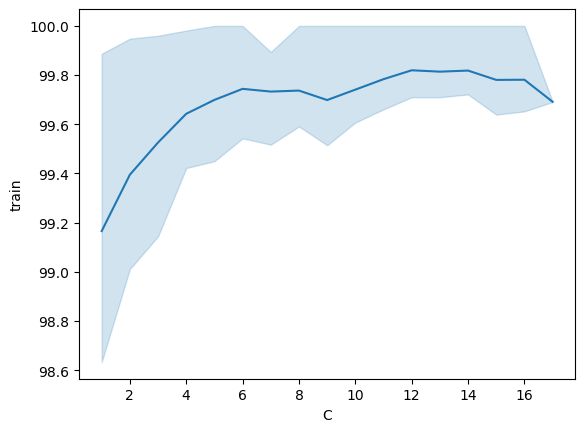

In [12]:
sns.lineplot(x='C', y='train', data=result_svc)

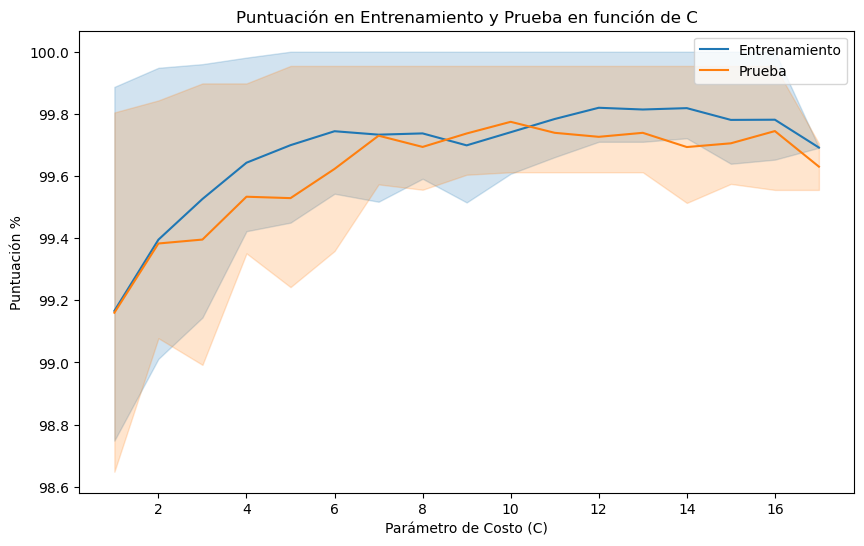

In [13]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='C', y='train', data=result_svc, label='Entrenamiento')
sns.lineplot(x='C', y='test', data=result_svc, label='Prueba')
plt.xlabel('Parámetro de Costo (C)')
plt.ylabel('Puntuación %')
plt.title('Puntuación en Entrenamiento y Prueba en función de C')

plt.legend()
plt.show()

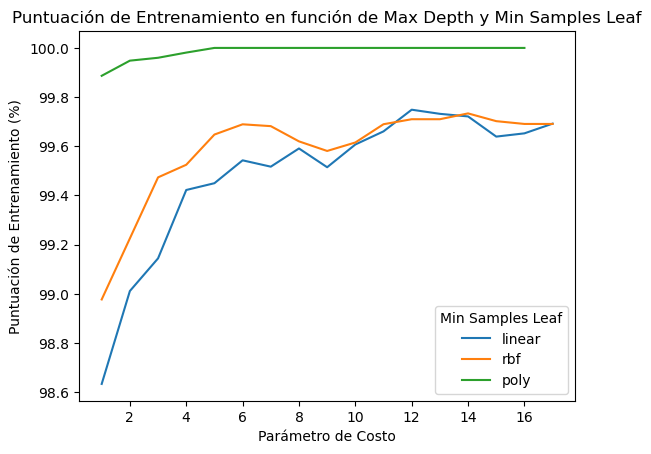

In [14]:
sns.lineplot(data=result_svc, x='C', y='train', hue='kernel')
#sns.lineplot(data=result1, x='max_depth', y='test', hue='min_samples_leaf')
plt.title('Puntuación de Entrenamiento en función de Max Depth y Min Samples Leaf')
plt.xlabel('Parámetro de Costo')
plt.ylabel('Puntuación de Entrenamiento (%)')
plt.legend(title='Min Samples Leaf')
plt.show()

# 7. A continuación, continuamos explorando parámetros para la optimización de nuestro código. En esta ocasión, añadiremos 'C (Parámetro de Costo)' como un parámetro a nuestro SVC.
* C (Parámetro de Costo):
* Kernel (Tipo de Kernel):
* Degree (Solo para kernel 'poly'): 
* Gamma (Solo para kernels 'rbf' y 'poly')

In [15]:
def train_svc(C, kernel, degree, x_asc, y_asc, data):
    SEED = 301
    np.random.seed(SEED)

    cv = GroupKFold(n_splits=8)
    modelo = SVC(C=C, kernel=kernel, degree=degree, gamma='auto', random_state=SEED)
    results = cross_validate(modelo, x_asc, y_asc, cv=cv, groups=data.STATE_PH_INT, return_train_score=True)
    
    train_score = results['train_score'].mean() * 100
    test_score = results['test_score'].mean() * 100
    
    print(f'SVC C = {C}, kernel = {kernel}, degree = {degree}, training = {train_score:.2f}, testing = {test_score:.2f}')

    tabla = [C, kernel, degree, round(train_score, 2), round(test_score, 2)]
    return tabla

def main():
    resultados_df = [
        train_svc(C=C, kernel=kernel, degree=degree, x_asc=x_asc, y_asc=y_asc, data=data)
        for C in range(1, 28)
        for kernel in ['linear', 'rbf', 'poly']
        for degree in [2, 3]  # Grados posibles para el kernel 'poly'
    ]

    resultados_df = pd.DataFrame(resultados_df, columns=['C', 'kernel', 'degree', 'train', 'test'])
    print(f"\n")
    return {'table': resultados_df.head(len(resultados_df)), 'result': resultados_df}

result_svc = main()
value_table_svc = result_svc['table']

# Mejor rendimiento obtenido con más de 2 hiperparámetros
# C = 2, kernel = poly, degree = 3
# Puntuación obtenida fue de 99.95

SVC C = 1, kernel = linear, degree = 2, training = 98.63, testing = 98.65
SVC C = 1, kernel = linear, degree = 3, training = 98.63, testing = 98.65
SVC C = 1, kernel = rbf, degree = 2, training = 99.15, testing = 99.17
SVC C = 1, kernel = rbf, degree = 3, training = 99.15, testing = 99.17
SVC C = 1, kernel = poly, degree = 2, training = 99.55, testing = 99.67
SVC C = 1, kernel = poly, degree = 3, training = 100.00, testing = 99.95
SVC C = 2, kernel = linear, degree = 2, training = 99.01, testing = 99.08
SVC C = 2, kernel = linear, degree = 3, training = 99.01, testing = 99.08
SVC C = 2, kernel = rbf, degree = 2, training = 99.53, testing = 99.38
SVC C = 2, kernel = rbf, degree = 3, training = 99.53, testing = 99.38
SVC C = 2, kernel = poly, degree = 2, training = 99.67, testing = 99.63
SVC C = 2, kernel = poly, degree = 3, training = 100.00, testing = 99.95
SVC C = 3, kernel = linear, degree = 2, training = 99.14, testing = 98.99
SVC C = 3, kernel = linear, degree = 3, training = 99.14

In [16]:
corr1 = result_svc.corr()
corr1

AttributeError: 'dict' object has no attribute 'corr'

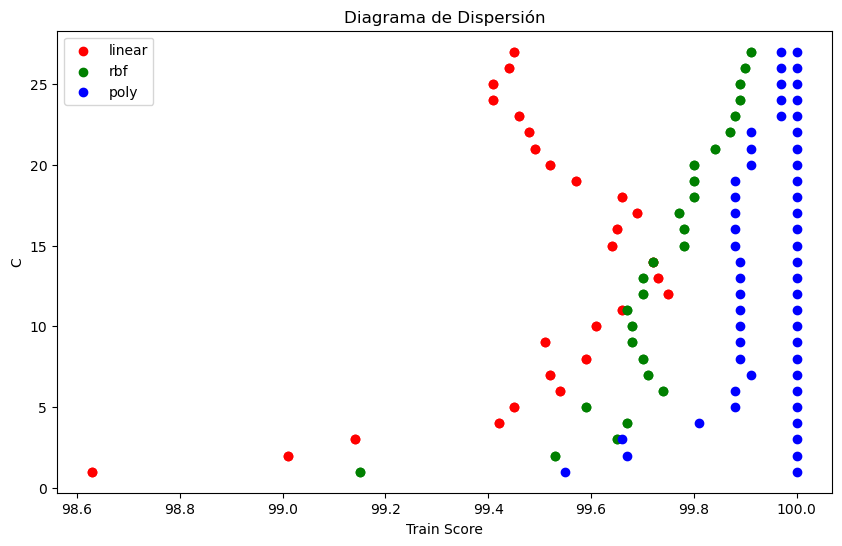

In [15]:
plt.figure(figsize=(10, 6))

cmap = plt.get_cmap('viridis') 

colores = {'linear': 'red', 'rbf': 'green', 'poly': 'blue'}

for kernel, color in colores.items():
    data = value_table_svc[value_table_svc['kernel'] == kernel]
    plt.scatter(data['train'], data['C'], c=color, label=kernel, cmap=cmap)

plt.xlabel('Train Score')
plt.ylabel('C')
plt.title('Diagrama de Dispersión')
plt.legend()
plt.show()


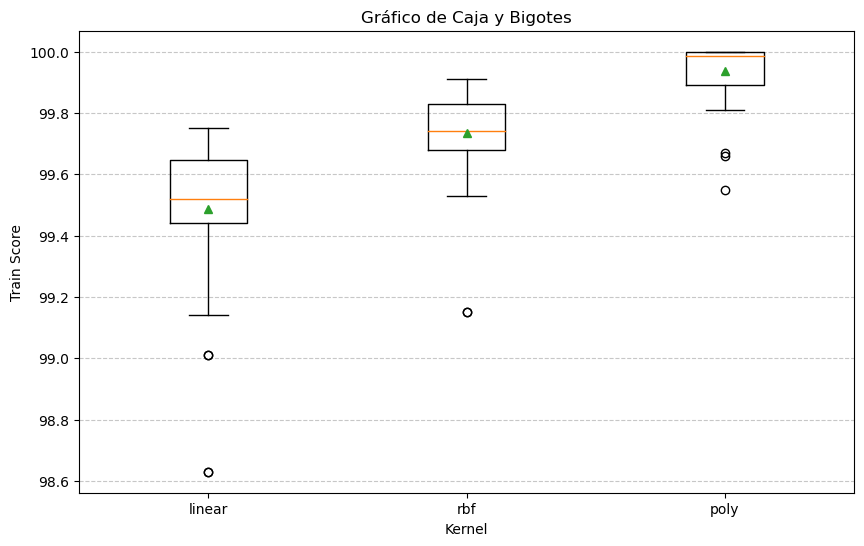

In [16]:
plt.figure(figsize=(10, 6))
grouped_data = [value_table_svc[value_table_svc['kernel'] == kernel]['train'] for kernel in value_table_svc['kernel'].unique()]
plt.boxplot(grouped_data, labels=value_table_svc['kernel'].unique(), showmeans=True)

plt.xlabel('Kernel')
plt.ylabel('Train Score')
plt.title('Gráfico de Caja y Bigotes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



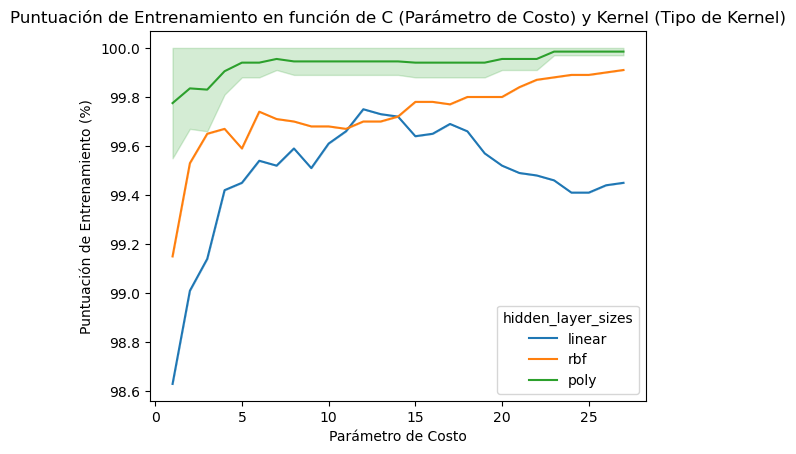

In [17]:
sns.lineplot(data=value_table_svc, x='C', y='train', hue='kernel')
plt.title('Puntuación de Entrenamiento en función de C (Parámetro de Costo) y Kernel (Tipo de Kernel)')
plt.xlabel('Parámetro de Costo')
plt.ylabel('Puntuación de Entrenamiento (%)')
plt.legend(title='hidden_layer_sizes')
plt.show()

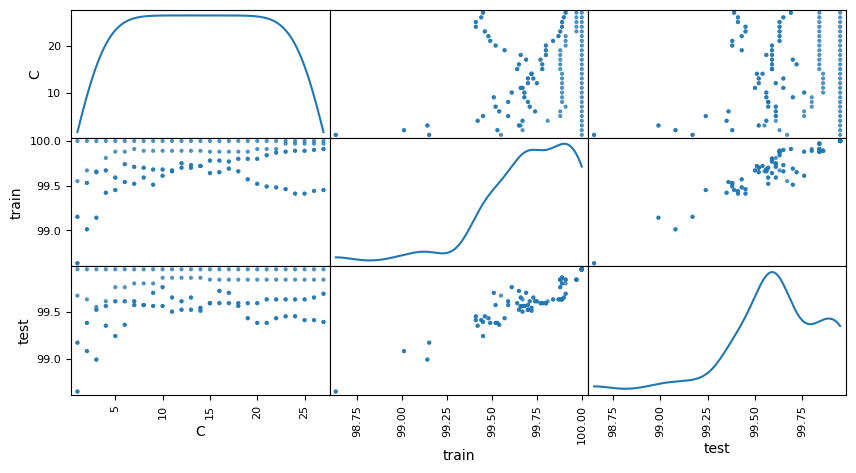

In [18]:
numeric_columns = ['C', 'train', 'test']
# Crea la matriz de dispersión
scatter_matrix(value_table_svc[numeric_columns], alpha=0.8, figsize=(10,5), diagonal='kde')
plt.show()

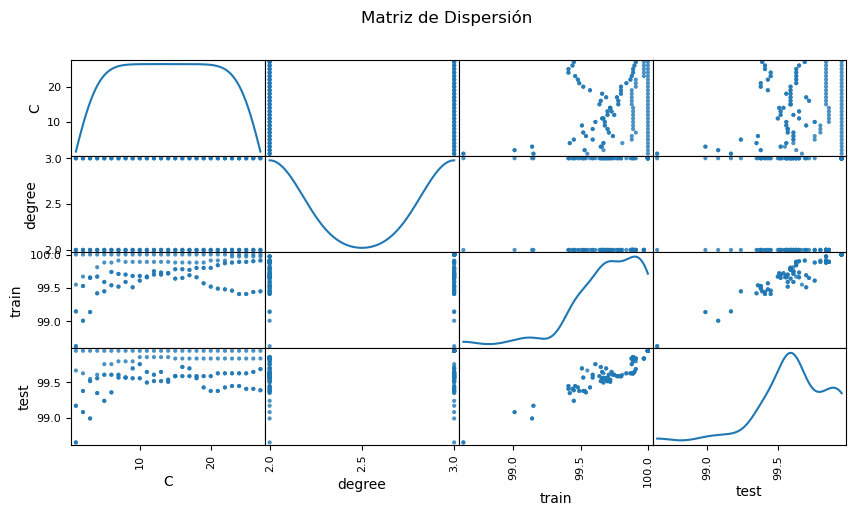

In [19]:
import string

columns_with_letters = [col for col in value_table_svc.columns if any(char in string.ascii_letters for char in col)]

scatter_matrix(value_table_svc[columns_with_letters], alpha=0.8, figsize=(10, 5), diagonal='kde')

plt.suptitle("Matriz de Dispersión")

plt.show()


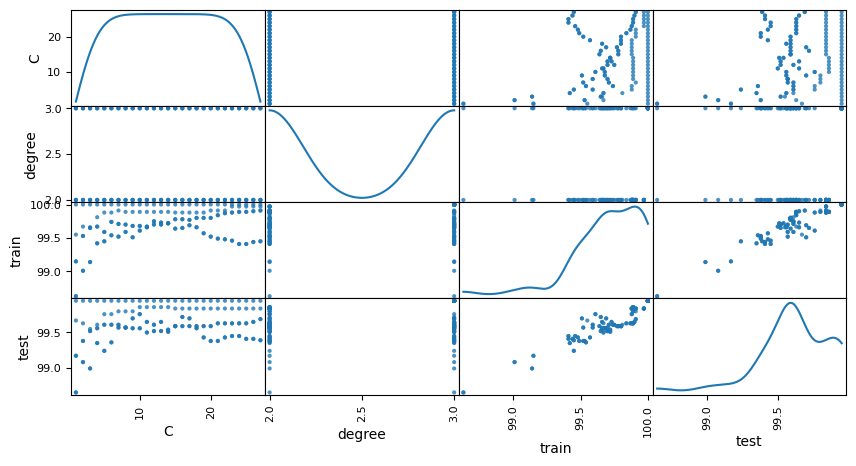

In [20]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
import string

columns_with_letters = [col for col in value_table_svc.columns if any(char in string.ascii_letters for char in col)]

scatter_matrix(value_table_svc[columns_with_letters], alpha=0.8, figsize=(10, 5), diagonal='kde')
plt.show()


# 8 Explorando 4 dimensiones de hiperparámetros utilizando GridSearchCV

In [21]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, KFold

SEED = 301
np.random.seed(SEED)

espacio_de_parametros = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'degree': [2, 3],
    'gamma': ['auto', 'scale']
}

search_end = GridSearchCV(SVC(),
                      espacio_de_parametros,
                      cv=KFold(n_splits=5, shuffle=True))

search_end.fit(x_asc, y_asc)
resultados = pd.DataFrame(search_end.cv_results_)
resultados.head()


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_degree,param_gamma,param_kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.048996,0.006842,0.032003,0.004898,0.1,2,auto,linear,"{'C': 0.1, 'degree': 2, 'gamma': 'auto', 'kern...",0.971645,0.960302,0.971645,0.971645,0.964015,0.967850,0.004793,33
1,0.064793,0.001720,0.107406,0.051029,0.1,2,auto,rbf,"{'C': 0.1, 'degree': 2, 'gamma': 'auto', 'kern...",0.984877,0.969754,0.986767,0.975425,0.981061,0.979577,0.006256,29
2,0.015599,0.002418,0.009799,0.003430,0.1,2,auto,poly,"{'C': 0.1, 'degree': 2, 'gamma': 'auto', 'kern...",0.998110,0.994329,0.994329,0.998110,0.994318,0.995839,0.001854,18
3,0.055398,0.003931,0.035801,0.002401,0.1,2,scale,linear,"{'C': 0.1, 'degree': 2, 'gamma': 'scale', 'ker...",0.971645,0.960302,0.971645,0.971645,0.964015,0.967850,0.004793,33
4,0.085382,0.009903,0.107217,0.013460,0.1,2,scale,rbf,"{'C': 0.1, 'degree': 2, 'gamma': 'scale', 'ker...",0.971645,0.960302,0.975425,0.973535,0.967803,0.969742,0.005351,31


In [22]:
scores = cross_val_score(search_end, x_asc, y_asc, cv = KFold(n_splits=5, shuffle=True))
scores_df = pd.DataFrame({'Cross_Val_Scores': scores})
scores_df

,Cross_Val_Scores
0,1.000000
1,0.998110
2,0.996219
3,1.000000
4,1.000000


In [23]:
mejor_estimator = search_end.best_estimator_
def print_score(scores):
  media = scores.mean() * 100
  desviacion = scores.std() * 100
  print("Accuracy media %.2f" % media)
  print("Intervalo [%.2f, %.2f]" % (media - 2 * desviacion, media + 2 * desviacion))
  print(search_end.best_params_)
  print(mejor_estimator)
  print(round(search_end.best_score_ * 100,2))
    
print_score(scores)

Accuracy media 99.89
Intervalo [99.58, 100.19]
{'C': 1, 'degree': 3, 'gamma': 'auto', 'kernel': 'poly'}
SVC(C=1, gamma='auto', kernel='poly')
99.96


In [24]:
prediccion = mejor_estimator.predict(x_asc)
accuracy = accuracy_score(prediccion, y_asc) * 100
print('Accuracy para los datos fue %.2f%% ' % accuracy)

Accuracy para los datos fue 100.00% 


# 9. Nuestro Codigo final del modelo SVC

In [25]:
x_train_,x_test_,y_train_,y_test_=train_test_split(x_asc,y_asc,test_size=0.25,random_state=301)

best_params={
    'C': 1,
    'kernel': 'poly',
    'degree': 3,
    'gamma':'auto'
}    

modelo=SVC(**best_params)
modelo.fit(x_test_,y_test_)

y_pred=modelo.predict(x_test_)
accuracy_m=modelo.score(x_test_,y_test_)

print(f"Exactitud en datos de prueba con modelo.score {round(accuracy_m*100,2)} %")

Exactitud en datos de prueba con modelo.score 100.0 %


### A continuación, evaluaremos nuestro modelo utilizando las siguientes métricas de clasificación: accuracy_score, precisión, recall y F1-Score. El objetivo es determinar el nivel de precisión de los resultados obtenidos por nuestro modelo entrenado y optimizado con los parámetros evaluados durante el entrenamiento.

In [26]:
accuracy_score_end = accuracy_score(y_test_, y_pred)
precision = precision_score(y_test_, y_pred, average='macro')
recall = recall_score(y_test_, y_pred, average='macro')
f1 = f1_score(y_test_, y_pred, average='macro')

print(f"Exactitud en datos de prueba con accuracy_score: {round(accuracy_score_end * 100, 2)} %")
print(f'Accuracy:  {round(accuracy_score_end*100,2)}')
print(f'Precisión: {round(precision*100,2)}')
print(f'Recall:    {round(recall*100,2)}')
print(f'F1-Score:  {round(f1*100,2)}')

Exactitud en datos de prueba con accuracy_score: 100.0 %
Accuracy:  100.0
Precisión: 100.0
Recall:    100.0
F1-Score:  100.0


In [27]:
# Modificando los resultados de las métricas para visualizarlos en una tabla
accuracy  = accuracy_score(y_test_, y_pred)
precision = precision_score(y_test_, y_pred, average='macro')
recall    = recall_score(y_test_, y_pred, average='macro')
f1        = f1_score(y_test_, y_pred, average='macro')

results_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Value': [round(accuracy_score_end*100,2), round(precision*100,2), round(recall*100,2), round(f1*100,2)]
})

# Mostrar el DataFrame
results_df


,Metric,Value
0,Accuracy,100.0
1,Precision,100.0
2,Recall,100.0
3,F1-Score,100.0


In [28]:
print(classification_report(y_test_, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        50
           2       1.00      1.00      1.00       176
           3       1.00      1.00      1.00       164
           4       1.00      1.00      1.00        94
           5       1.00      1.00      1.00        87
           6       1.00      1.00      1.00        27
           7       1.00      1.00      1.00        63

    accuracy                           1.00       661
   macro avg       1.00      1.00      1.00       661
weighted avg       1.00      1.00      1.00       661



# 10. Realizando pruebas finales 

In [31]:
x_data = [[3.0],[8.0],[0.9]]  # Datos para la predicción
y_predd = modelo.predict(x_data)

dt_stateString = pd.DataFrame(datos_asc)
pH_group_by = dt_stateString.groupby(['STATE_PH', 'STATE_PH_INT'])

for (ph, state_ph_int), group_data in pH_group_by:
    for pred in y_predd:
        if pred==state_ph_int:
             print(f"predicción: {ph} estado {state_ph_int}")

predicción: Extremadamente Ácido estado 1
predicción: Extremadamente Ácido estado 1
predicción: Moderadamente Alcalino estado 7


C:\Users\Rumijsd\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


DecisionTreeClasifier     RandomForestClassifier    SVC              MLPClassifier

Accuracy: 99.24                                    Accuracy :100.0   Accuracy :99.70
Precision: 97.77                                   Precision:100.0   Precision:99.25
Recall: 98.87                                      Recall   :100.0   Recall   :99.31
F1-Score: 98.2                                     F1-Score :100.0   F1-Score :99.28

Resultados de los modelos de entrenamiento> 

| DecisionTreeClasifier   |      RandomForestClassifier      |  SVC               | MLPClassifier   |
|-------------------------|:--------------------------------:|-------------------:|-----------------:
| Accuracy: 99.2          |     Accuracy :95.92              | Accuracy :100.0    | Accuracy :99.70 |
| Precision: 97.77        |     Precision:81.43              | Precision:100.0    | Precision:99.25 |
| Recall   : 98.87        |     Recall   :85.71              | Recall   :100.0    | Recall   :99.31 |
| F1-Score : 98.2         |     F1-Score :83.19              | F1-Score :100.0    | F1-Score :99.28 |